# Putting the pieces together

In [ ]:
# Imports and constants
import pandas as pd
from pathlib import Path
import torch
import transformer_lens
import gc
import itertools
import random
from sklearn.svm import LinearSVC
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns


# MODEL_NAME = "EleutherAI/pythia-410m"
MODEL_NAME = "microsoft/phi-2"

# Data generation
READ_FROM_FILE = True # If false, re-check all classifications and re-generate data files
DATA_FOLDER = "data-phase-state"
LIST_A_FILE_PATH = f"{DATA_FOLDER}/list_a.txt"
LIST_B_FILE_PATH = f"{DATA_FOLDER}/list_b.txt"
ALL_CANDIDATES = f"{DATA_FOLDER}/wikidata_chemical_compounds.csv"
# The next token
def GET_PROMPT(text, prefix=""):
    return f"{prefix}Q: In a single word, in what phase is {text} at room temperature?\nA:"
def IS_COMPLETION_IN_A(text, completion, prefix=""):
    return completion[len(GET_PROMPT(text, prefix)):].strip().lower().startswith('liquid')
def IS_COMPLETION_IN_B(text, completion, prefix=""):
    #return not IS_COMPLETION_IN_A(text, completion, prefix)
    return completion[len(GET_PROMPT(text, prefix)):].strip().lower().startswith('solid')
# What token do we want to study?
def GET_SHORT_PROMPT(text, prefix=""):
    return f"{prefix}Q: In a single word, in what phase is {text}"
SPACE_RANGE = range(0, 1, 1) # How many different spaces real data points get
RESTRICT_TO_TWO_TOKENS = True
GENERATE_FAKE_NAMES = False
FAKE_NAMES_MAX = 2000 # how many different fake names to generate
NUM_PREFIXES = 100 # How many different spaces fake data points get
LIMIT = 20000 # Max number of total data points per set

PLOT_SEPARATION = False
MAX_POINTS_IN_PLOT = 1000

MAX_BATCH_SIZE = 200

def DELTA(layer_idx):
    return 0.0

NUM_JOBS = -1 # How many parallel jobs for computing convex sets (max 1 per layer, -1 for all cores)

In [3]:
# Clear GPU, then load model
if "model" in locals() or "model" in globals():
    del model

torch.cuda.empty_cache()

gc.collect()

# 4. Verify memory is cleared
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

# Load the Pythia-2.8b model
# This will download the model weights if they are not already cached.
model = transformer_lens.HookedTransformer.from_pretrained_no_processing(
    MODEL_NAME,
    device="cuda" if torch.cuda.is_available() else "cpu",
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)

print(f"{MODEL_NAME} model loaded successfully.")

GPU memory allocated: 0.00 MB
GPU memory reserved: 0.00 MB


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  4.52it/s]


Loaded pretrained model microsoft/phi-2 into HookedTransformer
microsoft/phi-2 model loaded successfully.


In [4]:
# Load names from file
candidates_file = Path(ALL_CANDIDATES)
with open(candidates_file, "r") as f:
    candidates = f.read().strip().split("\n")
    print(f"{len(candidates)} candidates loaded from {ALL_CANDIDATES}.")

147275 candidates loaded from data-phase-state/wikidata_chemical_compounds.csv.


In [ ]:
if RESTRICT_TO_TWO_TOKENS:
    print("Restricting to names that are exactly two tokens long...")
    # A list to store names that consist of exactly two tokens
    two_token_names = []

    for candidate in candidates:
        # Tokenize the name. The result includes a batch dimension.
        tokens = model.to_tokens(candidate)

        # Check if the number of tokens (the length of the second dimension) is 3
        # (<soe> token, first name, last name)
        if tokens.shape[1] == 2:
            two_token_names.append(candidate)

    print(f"Found {len(two_token_names)} names that are exactly two tokens long.")
    print(two_token_names[:10])
    candidates = two_token_names

Restricting to names that are exactly two tokens long...
Found 23 names that are exactly two tokens long.
['carbon', 'tin', 'argon', 'lead', 'silver', 'iron', 'gold', 'water', 'ice', 'GV']


In [ ]:
def is_in_group_A(name, prefix=""):
    prompt = GET_PROMPT(name, prefix)
    completion = model.generate(prompt, max_new_tokens=1, temperature=0, verbose=False)
    return IS_COMPLETION_IN_A(name, completion, prefix)

# TODO: Define behaviour for group B (just not A, or explicitly check?)

# def is_basketball_player(name):
#     prompt = f"Fact: {name} is known for playing the sport of"
#     completion = model.generate(prompt, max_new_tokens=1, temperature=0, verbose=False)
#     completion_text = completion[len(prompt) :].strip()
#     return completion_text.lower().startswith("basketball")

prefix_candidates = [" " * i for i in SPACE_RANGE]

if READ_FROM_FILE:
    # Read A and B from file
    list_a_file = Path(LIST_A_FILE_PATH)
    with open(list_a_file, "r") as f:
        list_a = [line.rstrip() for line in f if line.rstrip()]
    print(f"Loaded {len(list_a)} entities from {list_a_file}")
else:
    # TODO: Keep cleaning from here
    # basketball_players = []
    print("Completions for basketball players:")
    print("---------------------------------------")

    # two_token_names = player_names
    list_a = []

    for candidate in candidates:
        if not is_basketball_player(candidate):
            continue
        list_a.append(candidate)
        print(".", end="")
        # Player without prefix passed, try to generate more data points:
        prefixed_names = [prefix + candidate for prefix in prefix_candidates]
        attempted = 0
        found = 0
        for prefixed_name in prefixed_names:
            attempted += 1
            if is_basketball_player(prefixed_name):
                list_a.append(prefixed_name)
                found += 1
            if attempted == 10 and found == 0:
                # If I can't find a second data point in the first 10 tries, abort
                break

    print("\n---------------------------------------")
    print(f"Found {len(list_a)} names that completed with 'basketball':")
    print(list_a[:10])

    random.shuffle(list_a)

    list_a_file = Path(f"{DATA_FOLDER}/basketball_players.txt")
    with open(list_a_file, "w") as f:
        f.write("\n".join(list_a))
    print(
        f"Stored {len(list_a)} basketball players in {list_a_file}."
    )

Loaded 41939 basketball players from data-2.8b/basketball_players.txt


In [ ]:
# READ_FROM_FILE = False

if READ_FROM_FILE:
    fake_basketball_players_file = Path(f"{DATA_FOLDER}/fake_basketball_players.txt")
    with open(fake_basketball_players_file, "r") as f:
        non_basketball_players = [line.rstrip() for line in f if line.rstrip()]
    print(
        f"Loaded {len(non_basketball_players)} basketball players from {fake_basketball_players_file}"
    )

else:
    # Use the list of confirmed basketball players from the previous step
    # Extract first and last names
    first_names = list(set([name.split(" ")[0] for name in list_a]))
    last_names = list(set([name.split(" ")[1] for name in list_a]))

    # Create all possible name combinations
    all_combinations = [" ".join(p) for p in itertools.product(first_names, last_names)]

    # Filter out the names that actually exist
    real_names_set = set(list_a)
    fake_names = [name for name in all_combinations if name not in real_names_set]
    # Pick 100 random fake names
    fake_names = random.sample(fake_names, min(FAKE_NAMES_MAX, len(fake_names)))
    # Add random prefixes:
    prefixed_fake_names = [prefix + name for name in fake_names for prefix in random.sample(prefix_candidates, NUM_PREFIXES)]

    # Combine original fake names with prefixed ones
    fake_names = fake_names + prefixed_fake_names

    print(f"Generated {len(fake_names)} fake names to test.")
    print(f"{fake_names[-20:]}")

    non_basketball_fake_players = []
    non_basketball_completions = []

    # Run basketball detection on the fake names
    for i, candidate in enumerate(fake_names):
        if not is_basketball_player(candidate):
            non_basketball_fake_players.append(candidate)
        if i % 100 == 9:
            print(".", end="")

    random.shuffle(non_basketball_fake_players)

    print(
        f"\nFound {len(non_basketball_fake_players)} fake names that are not associated with basketball."
    )

    fake_basketball_players_file = Path(f"{DATA_FOLDER}/fake_basketball_players.txt")
    with open(fake_basketball_players_file, "w") as f:
        f.write("\n".join(non_basketball_fake_players))
    print(
        f"Stored {len(non_basketball_fake_players)} fake basketball players in {fake_basketball_players_file}."
    )

Loaded 129893 basketball players from data-2.8b/fake_basketball_players.txt


In [38]:
model

HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-31): 32 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
    

In [39]:
# Switching to batched processing. Different token lengths mess up the values via padding, process
# same lengths together, this checks that the results are the same.
input = ["Prompt: Michael Jordan", "Prompt: Steve Curry"]

logits, v = model.run_with_cache(
    input,
    remove_batch_dim=False,
    names_filter=lambda layer: "hook_resid_post" in layer
    or "blocks.0.hook_mlp_in" in layer,  # Set to specific layers if needed
    incl_bwd=False,
    return_cache_object=False,
)

mj = v["blocks.0.hook_resid_post"][0]

logits2, v2 = model.run_with_cache(
    input[0],
    remove_batch_dim=True,
#     names_filter=lambda layer: "hook_resid_post" in layer
#     or "blocks.0.hook_mlp_in" in layer,  # Set to specific layers if needed
    incl_bwd=False,
    return_cache_object=False,
)

print(v['blocks.0.hook_resid_post'][0])
for l, v in v2.items():
    if "blocks.0" in l:
        print(f"{l}: {v.shape}")

a = v2["blocks.0.hook_resid_pre"][-1]
b = v2["blocks.0.hook_attn_out"][-1]
c = v2["blocks.0.hook_mlp_out"][-1]
print(f"blocks.0.hook_resid_pre: {v2['blocks.0.hook_resid_pre'][-1]}")
print(f"blocks.0.hook_attn_out: {v2['blocks.0.hook_attn_out'][-1]}")
print(f"blocks.0.hook_mlp_out: {v2['blocks.0.hook_mlp_out'][-1]}")
print(f"blocks.0.hook_resid_post: {v2['blocks.0.hook_resid_post'][-1]}")
print(f"{a+b+c}")

tensor([[ 0.6602, -0.3262,  0.0781,  ..., -0.3164, -0.6797,  1.2266],
        [ 0.4297, -0.0430, -0.3379,  ..., -0.9883, -0.7070, -0.1836],
        [ 0.1992,  0.8477,  0.1543,  ...,  0.6016,  0.2324, -0.2295],
        [-0.2891,  0.1484, -0.1592,  ..., -0.0361,  0.1963,  0.0898],
        [-0.0352,  0.3164, -0.1152,  ...,  0.3066,  0.3203,  0.3340],
        [ 0.2930, -0.0649,  0.0771,  ..., -0.1904,  0.7891,  0.5625]],
       device='cuda:0', dtype=torch.bfloat16)
blocks.0.hook_resid_pre: torch.Size([6, 2560])
blocks.0.ln1.hook_scale: torch.Size([6, 1])
blocks.0.ln1.hook_normalized: torch.Size([6, 2560])
blocks.0.attn.hook_q: torch.Size([6, 32, 80])
blocks.0.attn.hook_k: torch.Size([6, 32, 80])
blocks.0.attn.hook_v: torch.Size([6, 32, 80])
blocks.0.attn.hook_rot_q: torch.Size([6, 32, 80])
blocks.0.attn.hook_rot_k: torch.Size([6, 32, 80])
blocks.0.attn.hook_attn_scores: torch.Size([32, 6, 6])
blocks.0.attn.hook_pattern: torch.Size([32, 6, 6])
blocks.0.attn.hook_z: torch.Size([6, 32, 80])


In [40]:
# Clear memory
if "model" in locals() or "model" in globals():
    del model

torch.cuda.empty_cache()
gc.collect()

# Load model with memory optimizations
model = transformer_lens.HookedTransformer.from_pretrained_no_processing(
    MODEL_NAME, device="cuda", dtype=torch.float16
)

def sort_into_batches(names):
    per_length = {}
    for name in names:
        prompt = f"Fact: {name}"
        l = len(model.to_tokens(prompt)[0])
        # print(f"l={l} for {name}")
        if l in per_length:
            per_length[l].append(name)
        else:
            per_length[l] = [name]
    return per_length


# Function to process one name with memory optimization
def process_with_cache(names, caches):
    batch = [f"Fact: {name}" for name in names]

    _, cache = model.run_with_cache(
        batch,
        remove_batch_dim=False,
        names_filter=lambda layer: "hook_resid_post" in layer
        or "blocks.0.hook_resid_pre" in layer
        or "blocks.0.hook_attn_out",  # Set to specific layers if needed
        incl_bwd=False,
        return_cache_object=False,
    )
    # The mid-layer activation is the sum of the pre-activation and attention output,
    # the right hook does not exist for some reason.
    for i, name in enumerate(names):
        a = cache['blocks.0.hook_resid_pre'][i][-1]
        b = cache['blocks.0.hook_attn_out'][i][-1]
        caches[name] = {'blocks.0.hook_resid_mid': a + b}
    for layer, v in cache.items():
        if "hook_resid_post" not in layer:
            continue
        for i, name in enumerate(names):
            # Move the last token's activation to CPU and detach
            caches[name][layer] = v[i][-1].detach().cpu()

    return caches

def compute_caches(names):
    batched_names = sort_into_batches(names)
    caches = {}
    with torch.inference_mode():
        for length, batch in batched_names.items():
            print(f"Processing batch of length {length} with {len(batch)} names...")
            for i in range(0, len(batch), MAX_BATCH_SIZE):
                # Process in batches of MAX_BATCH_SIZE
                small_batch = batch[i:i + MAX_BATCH_SIZE]
                # print(f"{batch}")
                # for i, name in enumerate(names):
                # Process each name individually and save to disk
                try:
                    process_with_cache(small_batch, caches)
                    # print(name)
                    # Save each cache separately to avoid accumulating in memory
                    # torch.save(caches[name], f"cache/cache_{i}_{name.replace(' ', '_')}.pt")
                except Exception as e:
                    print(f"Error processing batch for length {length}: {e}")

                # Force cleanup
                torch.cuda.empty_cache()
                gc.collect()

                # if i % 1000 == 0:
                #     print(f"Step {i} of {len(names)}...")
                # print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
                # print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

    return caches

# Load player names
with open(f"{DATA_FOLDER}/basketball_players.txt", "r") as f:
    player_names = [line.rstrip() for line in f if line.rstrip()]
with open(f"{DATA_FOLDER}/fake_basketball_players.txt", "r") as f:
    fake_names = [line.rstrip() for line in f if line.rstrip()]

player_caches = compute_caches(player_names[:LIMIT])
print(f"Processed {len(player_caches)} player caches.")
fake_caches = compute_caches(fake_names[:LIMIT])
print(f"Processed {len(fake_caches)} fake player caches.")

Loaded pretrained model EleutherAI/pythia-2.8b into HookedTransformer
Processing batch of length 205 with 67 names...
Processing batch of length 135 with 95 names...
Processing batch of length 148 with 107 names...
Processing batch of length 150 with 116 names...
Processing batch of length 194 with 113 names...
Processing batch of length 195 with 77 names...
Processing batch of length 131 with 120 names...
Processing batch of length 146 with 83 names...
Processing batch of length 125 with 86 names...
Processing batch of length 147 with 95 names...
Processing batch of length 166 with 119 names...
Processing batch of length 156 with 83 names...
Processing batch of length 50 with 117 names...
Processing batch of length 74 with 90 names...
Processing batch of length 84 with 83 names...
Processing batch of length 160 with 76 names...
Processing batch of length 141 with 116 names...
Processing batch of length 52 with 90 names...
Processing batch of length 96 with 122 names...
Processing batc

In [ ]:
for candidate in player_caches:
    for key in player_caches[candidate]:
        player_caches[candidate][key] = player_caches[candidate][key].detach().cpu()
        print(f"{candidate.strip()}.{key}: {player_caches[candidate][key].shape} {player_caches[candidate][key]}")
        break
    break

Brad Stevens.blocks.0.hook_resid_mid: torch.Size([2560]) tensor([-0.4041,  0.1743, -0.3245,  ..., -0.0770, -0.1541,  0.2476],
       dtype=torch.float16)


In [42]:
def get_layer_name(layer):
    layer_name = f"blocks.{layer}.hook_resid_post"
    if layer == -1:
        layer_name = "blocks.0.hook_resid_mid"
    return layer_name


def make_point_thick(vector, extra_vectors=100, thickness=0.2):
    # Create the points +- thickness in each dimension, return vector of all points and original
    vectors = [vector]
    for dim in range(min(extra_vectors, len(vector))):
        # Create a new vector with the current dimension increased and decreased by thickness
        pos_vector = vector.copy()
        pos_vector[dim] += thickness
        vectors.append(pos_vector)
    return vectors


def get_point_set(
    caches, hook_name="blocks.0.hook_resid_post", extra_vectors=0, thickness=0.2
):
    # Create a list to hold all vectors
    vectors = []

    # Extract vectors from all players
    print(f"Collecting vectors from layer {hook_name}...")
    for name in caches.keys():
        try:
            # Extract the vector for this player
            vector = caches[name][hook_name]

            # Make sure it's on CPU and detached (in case it isn't already)
            vector = vector.detach().cpu()
            # Convert the tensor to a numpy array
            vector = vector.numpy()
            # Add to our collection
            vectors.extend(
                make_point_thick(
                    vector, extra_vectors=extra_vectors, thickness=thickness
                )
            )
        except KeyError as e:
            print(f"Skipping {name}: Missing '{hook_name}' in cache")
        except IndexError as e:
            print(f"Skipping {name}: No last element in '{hook_name}'")
    return vectors


player_layer_0 = get_point_set(
    player_caches, "blocks.0.hook_resid_mid", extra_vectors=0
)
fake_layer_0 = get_point_set(
    fake_caches, "blocks.0.hook_resid_mid", extra_vectors=0
)

In [43]:
def count_linear_separation(set_a, set_b):
    # Combine all vectors into a dataset and create labels
    X = np.vstack([set_a, set_b])
    y = np.array(["Player"] * len(set_a) + ["Fake"] * len(set_b))

    # Train a linear SVM classifier
    clf = LinearSVC(random_state=42, max_iter=10000)
    clf.fit(X, y)

    # Make predictions
    y_pred = clf.predict(X)

    # Count overall misclassifications
    misclassified = np.sum(y_pred != y)
    print(
        f"Total misclassified points: {misclassified} out of {len(y)} ({misclassified/len(y)*100:.2f}%)"
    )

    # Get misclassified by class
    fake_misclassified = np.sum((y_pred != y) & (y_pred == "Player") & (y == "Fake"))
    player_misclassified = np.sum((y_pred != y) & (y_pred == "Fake") & (y == "Player"))

    print(f"Fake points misclassified as players: {fake_misclassified}")
    print(f"Player points misclassified as fake: {player_misclassified}")
    return fake_misclassified, player_misclassified

if PLOT_SEPARATION:
    print(count_linear_separation(player_layer_0, fake_layer_0))

In [44]:
# Plot neighborhood visualization, compute linear separation

if PLOT_SEPARATION:

    # Initialize lists to store results
    layer_results = []
    misclassification_rates = []
    player_misclassified_counts = []
    fake_misclassified_counts = []
    accuracy_scores = []

    # Get the number of layers
    num_layers = model.W_K.shape[0]
    print(f"Analyzing linear separability across {num_layers} layers...")

    plot_every = 4

    n_rows = (num_layers // plot_every + 2) // 3 + 1
    fig, axs = plt.subplots(
        nrows=n_rows,
        ncols=3,
        figsize=(12, 4 * n_rows),
    )
    ax_idx = 0

    # Process each layer
    for layer in range(-1, num_layers):
        # Get vectors from this layer using existing functions
        layer_name = get_layer_name(layer)
        player_layer_vectors = get_point_set(
            player_caches, layer_name, extra_vectors=0
        )
        fake_layer_vectors = get_point_set(fake_caches, layer_name, extra_vectors=0)

        # Check linear separability using existing function
        print(f"\nLayer {layer}:")
        fake_mis, player_mis = count_linear_separation(player_layer_vectors, fake_layer_vectors)

        # Calculate metrics
        total_points = len(player_layer_vectors) + len(fake_layer_vectors)
        total_mis = fake_mis + player_mis
        accuracy = 1 - (total_mis / total_points)

        # Store results
        layer_results.append({
            "layer": layer,
            "player_count": len(player_layer_vectors),
            "fake_count": len(fake_layer_vectors),
            "fake_misclassified": fake_mis,
            "player_misclassified": player_mis,
            "total_misclassified": total_mis,
            "accuracy": accuracy
        })

        misclassification_rates.append(total_mis / total_points)
        player_misclassified_counts.append(player_mis)
        fake_misclassified_counts.append(fake_mis)
        accuracy_scores.append(accuracy)

        # Generate TSNE visualization for selected layers (to avoid too many plots)
        if layer % plot_every == 0 or layer == -1 or layer == num_layers - 1:
            # Combine vectors for visualization
            
            all_vectors = np.vstack([player_layer_vectors[:MAX_POINTS_IN_PLOT], fake_layer_vectors[:MAX_POINTS_IN_PLOT]])
            labels = ["player"] * min(len(player_layer_vectors), MAX_POINTS_IN_PLOT) + ["fake"] * min(len(fake_layer_vectors), MAX_POINTS_IN_PLOT)
            # def describe_prefix(name):
            #     spaces = len(name) - len(name.lstrip())
            #     if spaces == 0:
            #         return "no prefix"
            #     return f"<{(spaces//500 + 1) * 500} spaces"
            # def describe_prefix(name):
            #     first_letter = name.lstrip()[0]
            #     return f"starts with {first_letter}"
            # labels = [describe_prefix(name) for name in player_caches.keys()][:MAX_POINTS_IN_PLOT] + [describe_prefix(name) for name in fake_caches.keys()][:MAX_POINTS_IN_PLOT]
            # Apply TSNE
            tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(all_vectors)//5))
            embeddings = tsne.fit_transform(all_vectors)

            # Create plot
            scatter = sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], 
                    hue=labels, palette="Set1", ax = axs.flat[ax_idx])
            if layer != 20:
                scatter.legend_.remove()
            axs.flat[ax_idx].set_title(f"Layer {layer}")
            ax_idx += 1

    plt.tight_layout()
    plt.show()

    # Plot misclassification rates across layers
    plt.figure(figsize=(12, 6))
    plt.plot(range(-1, num_layers), misclassification_rates, marker='o', color='red')
    plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
    plt.xlabel('Layer')
    plt.ylabel('Misclassification Rate')
    plt.title('Linear Classifier Misclassification Rate by Layer')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot accuracy across layers
    plt.figure(figsize=(12, 6))
    plt.plot(range(-1, num_layers), accuracy_scores, marker='o', color='green')
    plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
    plt.xlabel('Layer')
    plt.ylabel('Classification Accuracy')
    plt.title('Linear Classifier Accuracy by Layer')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot misclassifications by category
    plt.figure(figsize=(12, 6))
    x = np.arange(-1, num_layers)
    width = 0.35
    plt.bar(x - width/2, player_misclassified_counts, width, label='Players Misclassified as Fake')
    plt.bar(x + width/2, fake_misclassified_counts, width, label='Fake Misclassified as Players')
    plt.xlabel('Layer')
    plt.ylabel('Number of Misclassifications')
    plt.title('Misclassification Counts by Category')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Find best layer for linear separation
    best_layer = np.argmax(accuracy_scores)
    print(f"\nBest layer for linear separation: Layer {best_layer}")
    print(f"Accuracy: {accuracy_scores[best_layer]*100:.2f}%")
    print(f"Misclassification rate: {misclassification_rates[best_layer]*100:.2f}%")

In [45]:
def print_distance_stats(set_a, set_b, stats_lists=None, equal=False):
    """
    Calculate and print distance statistics between two sets of vectors.

    Parameters:
    - set_a: First set of vectors
    - set_b: Second set of vectors
    - stats_lists: Optional dictionary containing lists to append stats to
                  with keys 'min', 'max', 'mean', 'median'
    """
    distances = []
    for i, a in enumerate(set_a):
        for j, b in enumerate(set_b):
            distance = np.linalg.norm(a - b)
            if equal and i == j:
                # Skip distances between the same points
                continue
            distances.append(distance)
    distances.sort()
    print(
        f"Points in A: {len(set_a)}, in B: {len(set_b)}, total distances: {len(distances)}"
    )
    print(
        f"Min: {distances[0]:.4f}, Mean: {np.mean(distances):.4f}, Median: {np.median(distances):.4f}, Max: {distances[-1]:.4f}"
    )

    if stats_lists is not None:
        if "min" in stats_lists:
            stats_lists["min"].append(distances[0])
        if "max" in stats_lists:
            stats_lists["max"].append(distances[-1])
        if "mean" in stats_lists:
            stats_lists["mean"].append(np.mean(distances))
        if "median" in stats_lists:
            stats_lists["median"].append(np.median(distances))


print_distance_stats(player_layer_0[:500], fake_layer_0[:500])

Points in A: 500, in B: 500, total distances: 250000
Min: 4.6328, Mean: 11.0234, Median: 10.7578, Max: 17.3281


In [46]:
from scipy.spatial.distance import cdist

def get_min_distance(points_a, points_b):
    distances = cdist(points_a, points_b, metric="euclidean")
    min_dist = np.min(distances)
    i, j = np.unravel_index(np.argmin(distances), distances.shape)
    return min_dist, i, j

# print(min_distance(player_layer_0, fake_layer_0))
# 16s: (np.float64(1.7858378876167593), np.int64(1760), np.int64(137))

Processing layers in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 224 concurrent workers.


Processing layer -1...
Processing layer 0...
Processing layer 1...
Processing layer 2...
Processing layer 3...
Processing layer 4...
Processing layer 5...
Processing layer 6...
Processing layer 7...
Processing layer 8...
Processing layer 9...
Processing layer 10...
Processing layer 11...
Processing layer 12...
Processing layer 13...
Processing layer 14...
Processing layer 15...
Processing layer 16...
Processing layer 17...
Processing layer 18...
Processing layer 19...
Processing layer 20...
Not a single convex set, proceeding with Kruskal's algorithm...
Processing layer 21...
Processing layer 22...
Processing layer 23...
Processing layer 24...
Processing layer 25...
Processing layer 26...
Processing layer 27...
Processing layer 28...
Processing layer 29...
Processing layer 30...
Processing layer 31...
All points in one convex set, returning the set...
All points in one convex set, returning the set...
All points in one convex set, returning the set...
All points in one convex set, retu

[Parallel(n_jobs=-1)]: Done   2 out of  33 | elapsed:  6.2min remaining: 95.5min


All points in one convex set, returning the set...
All points in one convex set, returning the set...
All points in one convex set, returning the set...
All points in one convex set, returning the set...


...

[Parallel(n_jobs=-1)]: Done  26 out of  33 | elapsed:  8.5min remaining:  2.3min


All points in one convex set, returning the set...
All points in one convex set, returning the set...
All points in one convex set, returning the set...
All points in one convex set, returning the set...
All points in one convex set, returning the set...
All points in one convex set, returning the set...


[Parallel(n_jobs=-1)]: Done  30 out of  33 | elapsed: 10.0min remaining:  1.0min


All points in one convex set, returning the set...
Not a single convex set, proceeding with Kruskal's algorithm...
Not a single convex set, proceeding with Kruskal's algorithm...
Not a single convex set, proceeding with Kruskal's algorithm...
Layer -1: 20000 player vectors collected, 20000 fake vectors collected.
16 clusters found.
73 negative clusters found.
Layer 0: 20000 player vectors collected, 20000 fake vectors collected.
1 clusters found.
1 negative clusters found.
Layer 1: 20000 player vectors collected, 20000 fake vectors collected.
1 clusters found.
15 negative clusters found.
Layer 2: 20000 player vectors collected, 20000 fake vectors collected.
1 clusters found.
2 negative clusters found.
Layer 3: 20000 player vectors collected, 20000 fake vectors collected.
1 clusters found.
1 negative clusters found.
Layer 4: 20000 player vectors collected, 20000 fake vectors collected.
1 clusters found.
1 negative clusters found.
Layer 5: 20000 player vectors collected, 20000 fake vecto

[Parallel(n_jobs=-1)]: Done  33 out of  33 | elapsed: 557.3min finished


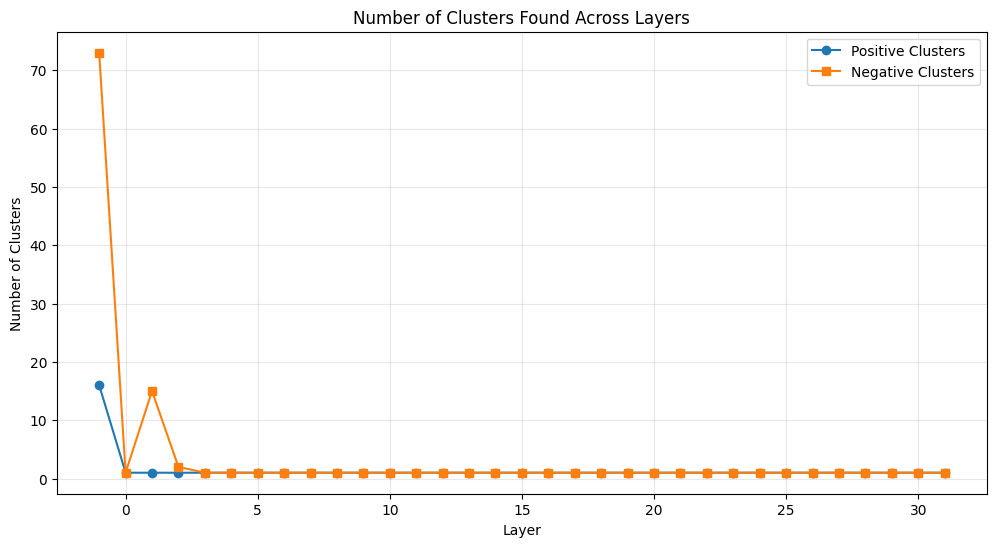

In [47]:
from convex_point_cover.algorithms.fast_kruskal import fast_kruskal

from joblib import Parallel, delayed

num_layers = model.W_K.shape[0]
layers = range(-1, num_layers)


def process_layer(layer, player_vectors, fake_vectors):
    print(f"Processing layer {layer}...")
    # min_distance, _, _ = get_min_distance(player_vectors, fake_vectors)
    # print(f"Layer {layer}: min distance={min_distance}")
    delta = DELTA(layer)
    # delta = min(min_distance - 0.11, 4)

    positive_clusters = fast_kruskal(
        player_vectors,
        fake_vectors,
        epsilon=0.1,
        delta=delta,
        debug=False,
    )
    negative_clusters = fast_kruskal(
        fake_vectors,
        player_vectors,
        epsilon=0.1,
        delta=delta,
        debug=False,
    )
    return {
        "layer": layer,
        "player_count": len(player_vectors),
        "fake_count": len(fake_vectors),
        "positive_clusters": len(positive_clusters),
        "negative_clusters": len(negative_clusters),
    }

# Run parallel computation - will use all available cores
print("Processing layers in parallel...")
results = Parallel(n_jobs=NUM_JOBS, verbose=10)(
    delayed(process_layer)(
        layer,
        get_point_set(
            player_caches,
            get_layer_name(layer),
            extra_vectors=0,
            thickness=0.2,
        ),
        get_point_set(
            fake_caches,
            get_layer_name(layer),
            extra_vectors=0,
            thickness=0.2,
        ),
    )
    for layer in layers
)

# Process and display results
cluster_sizes = [[], []]
for result in sorted(results, key=lambda x: x["layer"]):
    layer = result["layer"]
    player_count = result["player_count"]
    fake_count = result["fake_count"]
    pos_clusters = result["positive_clusters"]
    neg_clusters = result["negative_clusters"]

    # Store results
    cluster_sizes[0].append(pos_clusters)
    cluster_sizes[1].append(neg_clusters)

    # Print layer info
    print(
        f"Layer {layer}: {player_count} player vectors collected, {fake_count} fake vectors collected."
    )
    print(f"{pos_clusters} clusters found.")
    print(f"{neg_clusters} negative clusters found.")

# Plot the number of clusters found across layers
plt.figure(figsize=(12, 6))
plt.plot(layers, cluster_sizes[0], marker="o", label="Positive Clusters")
plt.plot(layers, cluster_sizes[1], marker="s", label="Negative Clusters")
plt.xlabel("Layer")
plt.ylabel("Number of Clusters")
plt.title("Number of Clusters Found Across Layers")
plt.legend()
plt.grid(True, alpha=0.3)


# Jump to End